In [9]:
import folium
from folium.plugins import HeatMap
import json
import requests
import networkx as nx
import matplotlib.colors as mcolors
import seaborn as sns
from math import log
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('HappinesssGlobalData_v6.csv')

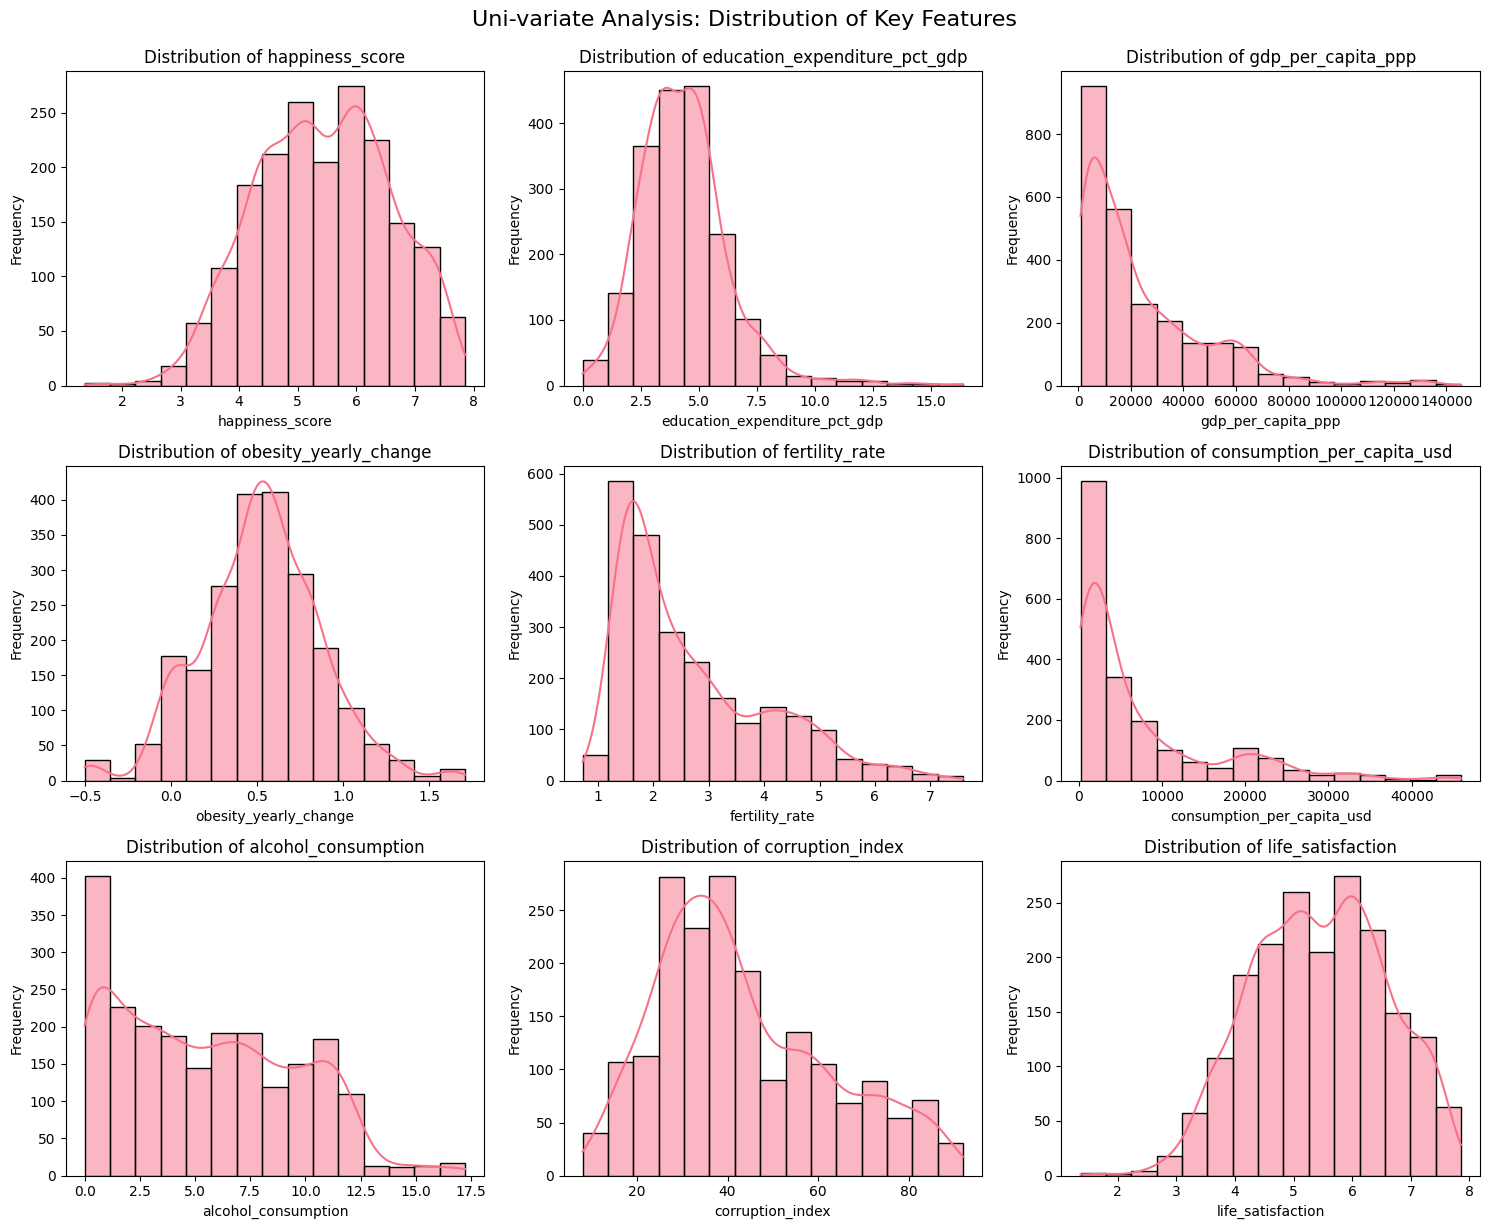

In [10]:
# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Select major features for intro-level EDA
features = [
    "happiness_score",
    "education_expenditure_pct_gdp", 
    "gdp_per_capita_ppp",
    "obesity_yearly_change",
    "fertility_rate",
    "consumption_per_capita_usd",
    "alcohol_consumption",
    "corruption_index",
    "life_satisfaction"
]

# Filter available features from your dataset
available_features = [f for f in features if f in df.columns]

# Create subplots for uni-variate analysis
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(available_features):
    if i < len(axes):
        # Histogram with KDE
        sns.histplot(df[feature].dropna(), kde=True, ax=axes[i], bins=15)
        axes[i].set_title(f'Distribution of {feature}', fontsize=12)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Uni-variate Analysis: Distribution of Key Features', fontsize=16, y=1.02)
plt.show()

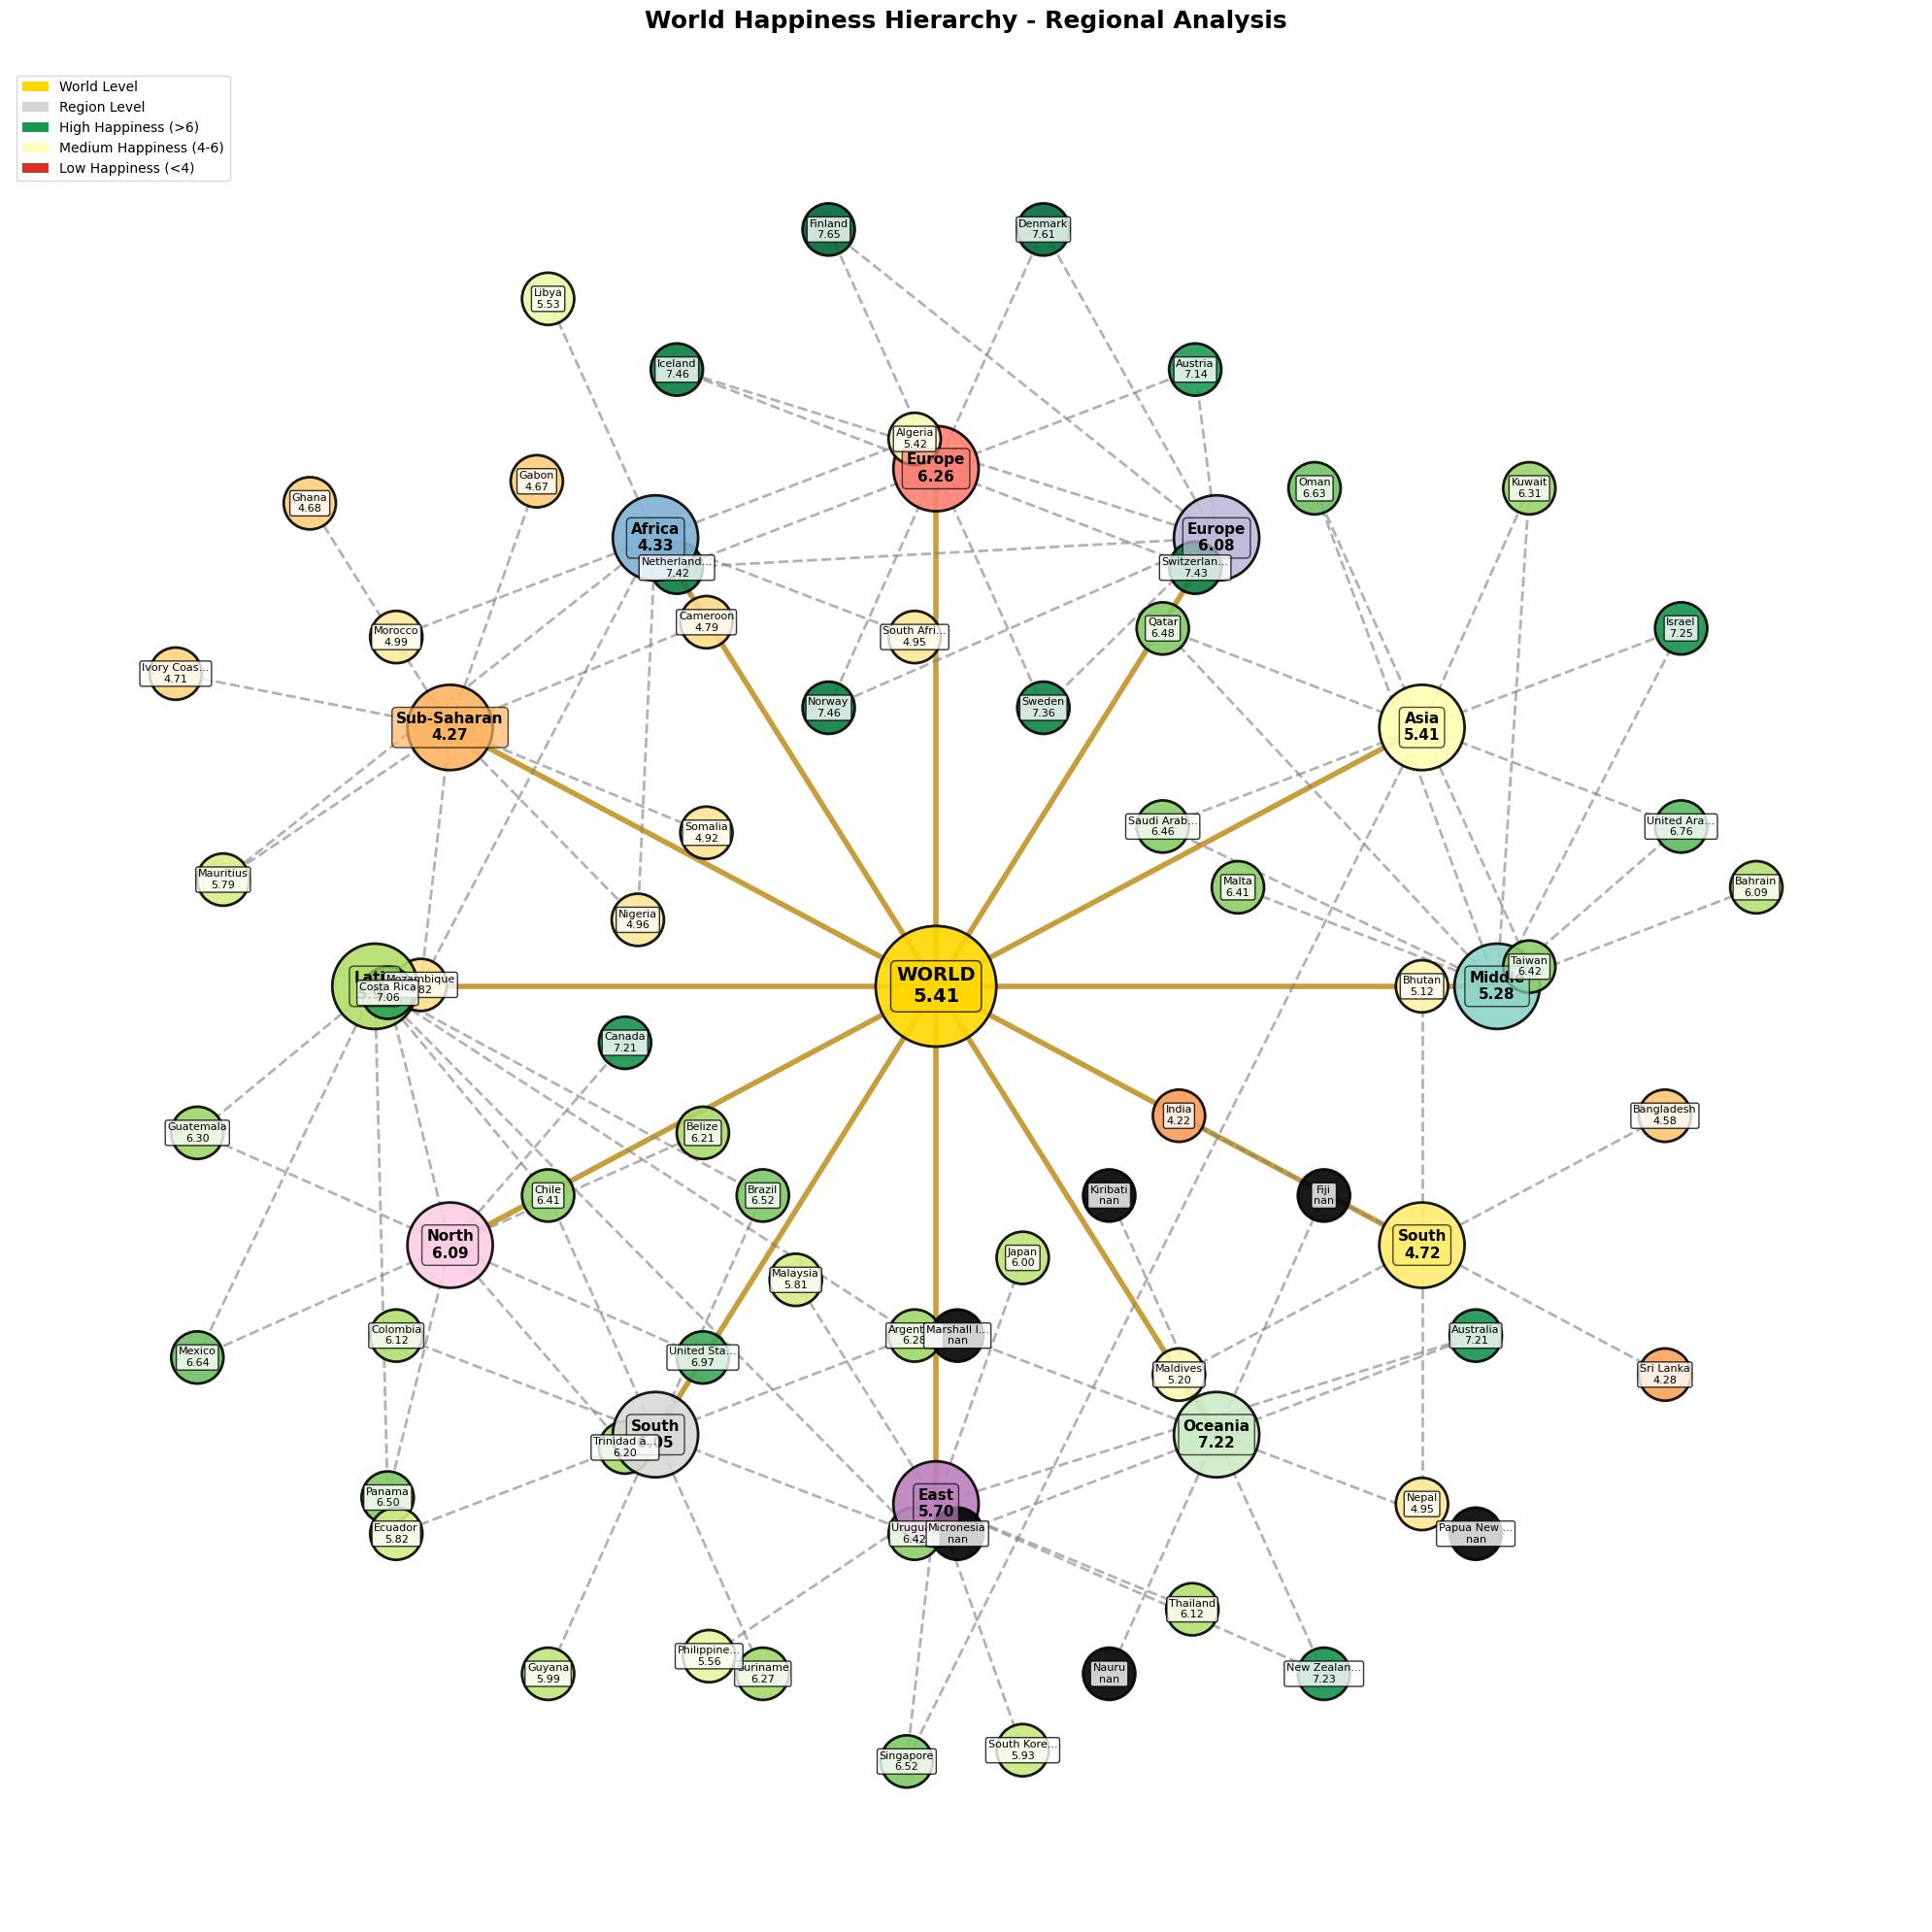

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Calculate average metrics by country using important features
country_metrics = df.groupby('country').agg({
    'happiness_score': 'mean',
    'gdp_per_capita_ppp': 'mean',
    'education_expenditure_pct_gdp': 'mean',
    'health_expenditure_per_capita_usd': 'mean',
    'corruption_index': 'mean',
    'life_satisfaction': 'mean',
    'alcohol_consumption': 'mean',
    'urban_population_pct': 'mean',
    'unemployment_rate': 'mean'
}).reset_index()

country_metrics.columns = ['country', 'avg_happiness', 'avg_gdp_ppp', 'avg_education_exp', 
                          'avg_health_exp', 'avg_corruption', 'avg_life_satisfaction',
                          'avg_alcohol', 'avg_urbanization', 'avg_unemployment']

# Use the existing region column from your dataset
region_data = df[['country', 'region']].drop_duplicates()
country_metrics = country_metrics.merge(region_data, on='country', how='left')

# Create comprehensive regional analysis
regional_analysis = country_metrics.groupby('region').agg({
    'avg_happiness': ['mean', 'std', 'count'],
    'avg_gdp_ppp': 'mean',
    'avg_education_exp': 'mean',
    'avg_health_exp': 'mean',
    'avg_corruption': 'mean',
    'avg_alcohol': 'mean',
    'avg_urbanization': 'mean',
    'avg_unemployment': 'mean'
}).round(3)

plt.figure(figsize=(20, 20))
# Create graph
G_radial = nx.Graph()

# Calculate positions manually for proper radial layout
def create_radial_positions(G, center_node, second_layer_nodes, third_layer_nodes):
    pos = {}
    
    # Center node
    pos[center_node] = (0, 0)
    
    # Second layer (regions) - placed in a circle
    num_regions = len(second_layer_nodes)
    region_radius = 3
    for i, region in enumerate(second_layer_nodes):
        angle = 2 * np.pi * i / num_regions
        x = region_radius * np.cos(angle)
        y = region_radius * np.sin(angle)
        pos[region] = (x, y)
    
    # Third layer (countries) - placed in circles around their regions
    country_radius = 1.5
    for region in second_layer_nodes:
        region_countries = [node for node in third_layer_nodes if G.has_edge(region, node)]
        num_countries = len(region_countries)
        
        if num_countries > 0:
            region_pos = pos[region]
            for j, country in enumerate(region_countries):
                angle = 2 * np.pi * j / num_countries
                x = region_pos[0] + country_radius * np.cos(angle)
                y = region_pos[1] + country_radius * np.sin(angle)
                pos[country] = (x, y)
    
    return pos

# Prepare data for radial plot
regions = country_metrics['region'].dropna().unique()
countries = country_metrics['country'].values

# Center node - using global average happiness
global_avg_happiness = country_metrics['avg_happiness'].mean()
G_radial.add_node('World', size=8000, color='gold', happiness=global_avg_happiness)

# Second layer: Regions
region_colors = plt.cm.Set3(np.linspace(0, 1, len(regions)))
region_color_map = {region: color for region, color in zip(regions, region_colors)}

for i, region in enumerate(regions):
    region_data = country_metrics[country_metrics['region'] == region]
    region_avg = region_data['avg_happiness'].mean()
    G_radial.add_node(region, size=4000, color=region_color_map[region], happiness=region_avg)
    G_radial.add_edge('World', region)
    
    # Third layer: Countries (limit to top countries per region for readability)
    top_countries = region_data.nlargest(8, 'avg_happiness')  # Show top 8 countries per region
    
    for _, country_row in top_countries.iterrows():
        country = country_row['country']
        happiness = country_row['avg_happiness']
        
        # Color countries based on happiness score
        norm_happiness = (happiness - country_metrics['avg_happiness'].min()) / (country_metrics['avg_happiness'].max() - country_metrics['avg_happiness'].min())
        country_color = plt.cm.RdYlGn(norm_happiness)
        
        G_radial.add_node(country, size=1500, color=country_color, happiness=happiness)
        G_radial.add_edge(region, country)

# Create manual radial layout
pos = create_radial_positions(G_radial, 'World', regions, countries)

# Draw nodes with colors and sizes
node_colors = [G_radial.nodes[node]['color'] for node in G_radial.nodes()]
node_sizes = [G_radial.nodes[node]['size'] for node in G_radial.nodes()]

# Draw with better styling
nx.draw_networkx_nodes(G_radial, pos, 
                      node_color=node_colors, 
                      node_size=node_sizes, 
                      alpha=0.9,
                      edgecolors='black',
                      linewidths=2)

# Draw edges with different styles for each layer
world_edges = [(u, v) for u, v in G_radial.edges() if u == 'World' or v == 'World']
region_edges = [(u, v) for u, v in G_radial.edges() if u not in ['World'] and v not in ['World'] and (u in regions or v in regions)]

nx.draw_networkx_edges(G_radial, pos, 
                      edgelist=world_edges,
                      edge_color='darkgoldenrod',
                      width=4,
                      alpha=0.8,
                      style='-')

nx.draw_networkx_edges(G_radial, pos, 
                      edgelist=region_edges,
                      edge_color='gray',
                      width=2,
                      alpha=0.6,
                      style='--')

# Add labels with better formatting
labels = {}
for node in G_radial.nodes():
    happiness = G_radial.nodes[node]['happiness']
    if node == 'World':
        labels[node] = f'WORLD\n{happiness:.2f}'
    elif node in regions:
        # Shorten region names for better display
        short_name = node.split()[0] if ' ' in node else node[:10]
        labels[node] = f'{short_name}\n{happiness:.2f}'
    else:
        # Shorten country names and show happiness
        short_name = node[:10] + '...' if len(node) > 10 else node
        labels[node] = f'{short_name}\n{happiness:.2f}'

# Draw labels with different font sizes
label_pos = {k: (v[0], v[1]) for k, v in pos.items()}
for node, (x, y) in pos.items():
    if node == 'World':
        plt.text(x, y, labels[node], 
                fontsize=14, fontweight='bold', 
                ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='gold', alpha=0.8))
    elif node in regions:
        plt.text(x, y, labels[node], 
                fontsize=11, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor=region_color_map[node], alpha=0.7))
    else:
        plt.text(x, y, labels[node], 
                fontsize=8, fontweight='normal',
                ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# Add legend for happiness colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gold', label='World Level'),
    Patch(facecolor='lightgray', label='Region Level'),
    Patch(facecolor=plt.cm.RdYlGn(0.9), label='High Happiness (>6)'),
    Patch(facecolor=plt.cm.RdYlGn(0.5), label='Medium Happiness (4-6)'),
    Patch(facecolor=plt.cm.RdYlGn(0.1), label='Low Happiness (<4)')
]

plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), fontsize=10)

plt.title('World Happiness Hierarchy - Regional Analysis', 
          size=18, pad=30, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
import plotly.express as px
import math

# Prepare data for sunburst using region instead of continent
sunburst_data = []

# Add country nodes
for _, row in country_metrics.iterrows():
    if pd.notna(row['region']):  # Only include countries with region data
        sunburst_data.append({
            'id': row['country'],
            'parent': row['region'],
            'value': 1,  # Use equal value for all countries to ensure equal spacing
            'happiness': row['avg_happiness'],
            'label': f"{row['country']}: {row['avg_happiness']:.2f}",
            'gdp': row['avg_gdp_ppp'],
            'health_exp': row['avg_health_exp'],
            'corruption': row['avg_corruption']
        })

# Calculate region values based on number of countries (for proper spacing)
region_counts = country_metrics.groupby('region').size()

# Add region nodes
for region in country_metrics['region'].dropna().unique():
    region_data = country_metrics[country_metrics['region'] == region]
    region_avg = region_data['avg_happiness'].mean()
    region_gdp = region_data['avg_gdp_ppp'].mean()
    region_health = region_data['avg_health_exp'].mean()
    region_corruption = region_data['avg_corruption'].mean()
    
    sunburst_data.append({
        'id': region,
        'parent': 'World',
        'value': region_counts[region],  # Value = number of countries for proper spacing
        'happiness': region_avg,
        'label': f"{region}: {region_avg:.2f}",
        'gdp': region_gdp,
        'health_exp': region_health,
        'corruption': region_corruption
    })

# Add world node
world_avg = country_metrics['avg_happiness'].mean()
world_gdp = country_metrics['avg_gdp_ppp'].mean()
world_health = country_metrics['avg_health_exp'].mean()
world_corruption = country_metrics['avg_corruption'].mean()
total_countries = len(country_metrics)

sunburst_data.append({
    'id': 'World',
    'parent': '',
    'value': total_countries,  # Total countries for proper spacing
    'happiness': world_avg,
    'label': f"World: {world_avg:.2f}",
    'gdp': world_gdp,
    'health_exp': world_health,
    'corruption': world_corruption
})

# Convert to DataFrame for Plotly
sunburst_df = pd.DataFrame(sunburst_data)

# Create sunburst with Viridis color scheme and proper spacing
fig_sunburst = px.sunburst(
    sunburst_df,
    names='id',
    parents='parent',
    values='value',  # Using count-based values for equal spacing
    title='World Happiness Distribution by Region and Country<br><sub>Color: Happiness Score | Equal spacing for all countries</sub>',
    color='happiness',  # Color by happiness but size by count
    color_continuous_scale='Viridis',
    hover_data={
        'label': True,
        'gdp': ':.0f',
        'health_exp': ':.0f',
        'corruption': ':.1f',
        'happiness': ':.2f'
    },
    custom_data=['gdp', 'health_exp', 'corruption', 'happiness'],
    branchvalues='total'  # This ensures the values are treated as totals
)

# Update hover template to show additional metrics
fig_sunburst.update_traces(
    hovertemplate='<b>%{label}</b><br>' +
                  'Happiness: %{customdata[3]:.2f}<br>' +
                  'GDP per capita: $%{customdata[0]:,.0f}<br>' +
                  'Health Expenditure: $%{customdata[1]:.0f}<br>' +
                  'Corruption Index: %{customdata[2]:.1f}<extra></extra>',
    textinfo='label',  # Show labels on the segments
    insidetextorientation='radial'  # Better text orientation
)

# Update layout for better appearance
fig_sunburst.update_layout(
    width=1000,
    height=1000,
    font=dict(size=10, family='Arial'),
    title_x=0.5,
    title_font_size=16,
    coloraxis_colorbar=dict(
        title="Happiness Score",
        thickness=20,
        len=0.75
    ),
    margin=dict(t=100, l=20, r=20, b=20)
)

# Add annotations for key insights
fig_sunburst.add_annotation(
    text="Each country occupies equal space in the circle<br>Hover over segments to see detailed metrics",
    xref="paper", yref="paper",
    x=0.5, y=-0.05,
    showarrow=False,
    font=dict(size=10, color="gray"),
    align="center"
)

fig_sunburst.show()

In [13]:
import folium

# Calculate average happiness by country
happiness_avg = df.groupby('country')['happiness_score'].mean().reset_index()

# Get world coordinates data
world_geo = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json'

# Create base map
m1 = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')

# Create choropleth
folium.Choropleth(
    geo_data=world_geo,
    name='Happiness Choropleth',
    data=happiness_avg,
    columns=['country', 'happiness_score'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Average Happiness Score',
    bins=8,
    reset=True,
    nan_fill_color='gray'  # Color for countries with no data
).add_to(m1)

# Add hover functionality
style_function = lambda feature: {
    'fillColor': 'gray',
    'color': 'black',
    'weight': 0.5,
    'fillOpacity': 0.1
}

# Create a GeoJson layer for hover effects
geojson = folium.GeoJson(
    world_geo,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['name'],
        aliases=['Country: '],
        localize=True
    )
).add_to(m1)

folium.LayerControl().add_to(m1)


m1.save('GlobalHappiness.html')
m1

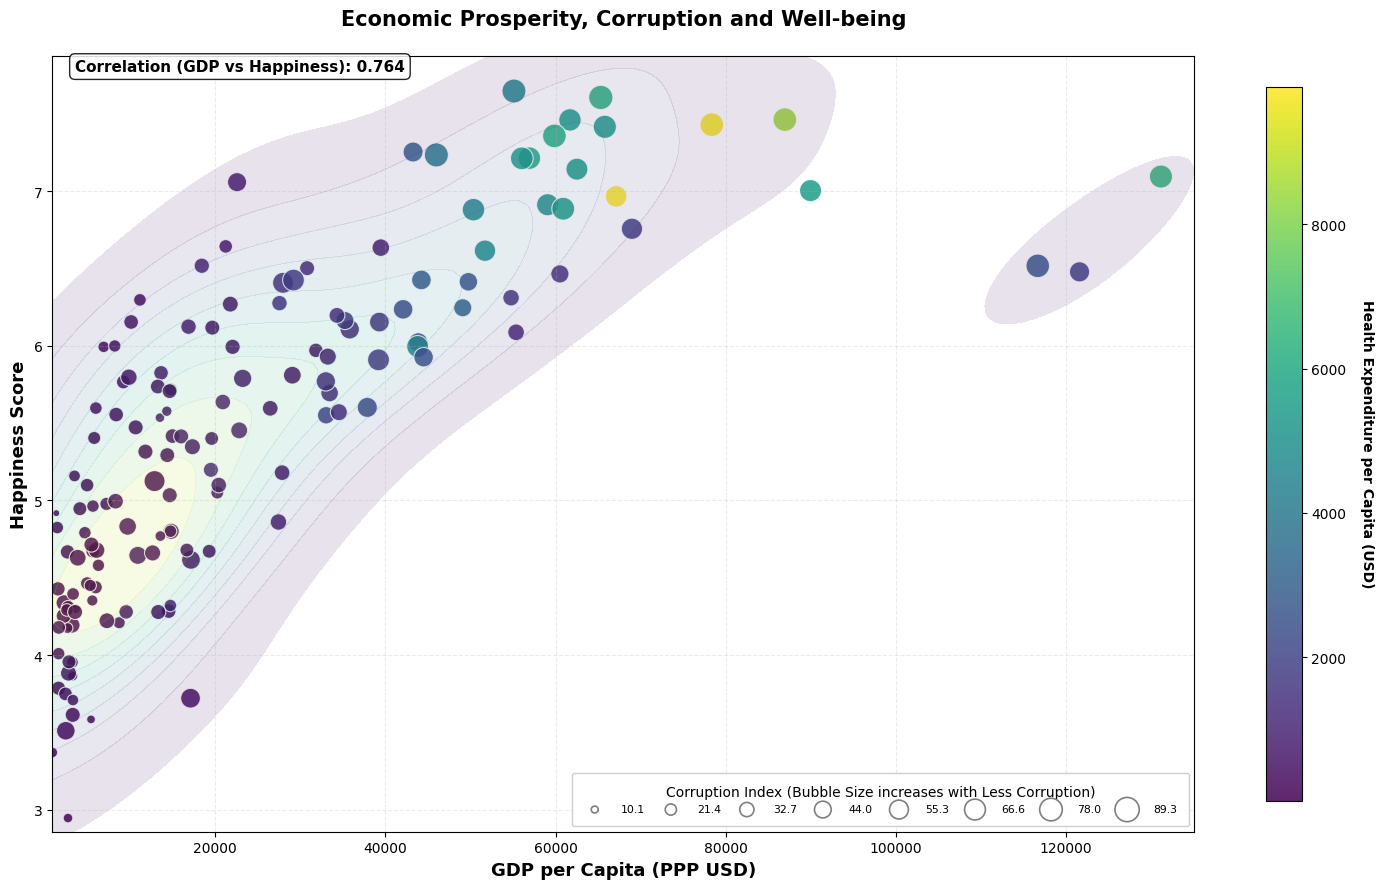

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches

# Set up the aesthetic style
plt.style.use('default')
sns.set_palette("husl")

# Define region mapping for your dataset
region_mapping = {
    'Asia': ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Cambodia', 'China', 'Cyprus', 'India', 'Indonesia', 'Japan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'Oman', 'Pakistan', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Taiwan', 'Tajikistan', 'Thailand', 'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'],
    'Europe & Central Asia': ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom', 'Vatican City'],
    'Middle East & North Africa': ['Algeria', 'Bahrain', 'Egypt', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Kuwait', 'Lebanon', 'Libya', 'Morocco', 'Oman', 'Palestine', 'Qatar', 'Saudi Arabia', 'Syria', 'Tunisia', 'United Arab Emirates', 'Yemen'],
    'Sub-Saharan Africa': ['Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'DR Congo', 'Djibouti', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Ivory Coast', 'Kenya', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Uganda', 'Zambia', 'Zimbabwe'],
    'North America': ['Canada', 'United States', 'Mexico', 'Antigua and Barbuda', 'Bahamas', 'Barbados', 'Belize', 'Costa Rica', 'Cuba', 'Dominica', 'Dominican Republic', 'El Salvador', 'Grenada', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica', 'Nicaragua', 'Panama', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Trinidad and Tobago'],
    'South America': ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela'],
    'Australia & Oceania': ['Australia', 'New Zealand', 'Fiji', 'Papua New Guinea', 'Solomon Islands', 'Vanuatu', 'Samoa', 'Kiribati', 'Micronesia', 'Tonga', 'Marshall Islands', 'Palau', 'Tuvalu', 'Nauru']
}

def get_region(country):
    for region, countries in region_mapping.items():
        if country in countries:
            return region
    return 'Other'

# --- Country-level feature aggregation ---
country_analysis = df.groupby('country').agg({
    'happiness_score': 'mean',
    'gdp_per_capita_ppp': 'mean',
    'health_expenditure_per_capita_usd': 'mean',
    'corruption_index': 'mean',
    'urban_population_pct': 'mean',
    'life_satisfaction': 'mean'
}).reset_index()

country_analysis.columns = [
    'country', 'avg_happiness', 'avg_gdp', 'avg_health_exp',
    'avg_corruption', 'avg_urbanization', 'avg_life_satisfaction'
]

country_analysis['region'] = country_analysis['country'].apply(get_region)
country_analysis = country_analysis.dropna()


# What the contours mean in this plot
# They show where countries are more concentrated.
# Darker or more intense contour regions = many countries fall in this area
# Lighter regions = fewer countries
# Areas with no contour = very sparse or no data
# It is a Kernel Density Estimate (KDE) applied over two variables


# Continuous bubble size scaling (reduced overall sizes)
corr = country_analysis['avg_corruption']
corr_scaled = (corr - corr.min()) / (corr.max() - corr.min())
bubble_sizes = 25 + corr_scaled * 280   # continuous 25 → 305 (slightly smaller)

# Create large visualisation
fig, ax = plt.subplots(figsize=(15, 9))

# MAIN SCATTER
scatter = ax.scatter(
    country_analysis['avg_gdp'],
    country_analysis['avg_happiness'],
    s=bubble_sizes,
    c=country_analysis['avg_health_exp'],
    cmap='viridis',
    alpha=0.85,
    edgecolors='white',
    linewidth=0.8
)

# ------------------------------------------------------------
# SOFTER KDE CONTOURS (less color, less opacity)
# ------------------------------------------------------------
sns.kdeplot(
    data=country_analysis,
    x='avg_gdp',
    y='avg_happiness',
    fill=True,
    cmap='viridis',
    alpha=0.12,          # decreased from 0.22 → 0.12
    levels=10,           # between 5–10, moderate detail
    linewidths=0.55,
    ax=ax
)

# LABELS & TITLE
ax.set_xlabel('GDP per Capita (PPP USD)', fontsize=13, fontweight='bold')
ax.set_ylabel('Happiness Score', fontsize=13, fontweight='bold')
ax.set_title(
    'Economic Prosperity, Corruption and Well-being',
    fontsize=15, fontweight='bold',
    pad=22
)

ax.grid(True, linestyle='--', alpha=0.25)

# ZOOM INTO DATA
ax.set_xlim(country_analysis['avg_gdp'].min() * 0.97,
            country_analysis['avg_gdp'].max() * 1.03)
ax.set_ylim(country_analysis['avg_happiness'].min() * 0.97,
            country_analysis['avg_happiness'].max() * 1.03)

# COLORBAR
cbar = plt.colorbar(scatter, ax=ax, shrink=0.92)
cbar.set_label('Health Expenditure per Capita (USD)',
               rotation=270, labelpad=20, fontweight='bold')

# ------------------------------------------------------------
# HORIZONTAL BUBBLE LEGEND (8 bubble sizes = between 5 and 10)
# ------------------------------------------------------------
min_c = corr.min()
max_c = corr.max()

legend_levels = np.linspace(min_c, max_c, 8)     # 8 sizes
legend_sizes = 25 + ((legend_levels - min_c) / (max_c - min_c)) * 280

legend_handles = [
    ax.scatter([], [], s=s,
               edgecolors='gray', facecolors='none',
               linewidth=1.2)
    for s in legend_sizes
]

legend_labels = [f"{v:.1f}" for v in legend_levels]

bubble_legend = ax.legend(
    legend_handles,
    legend_labels,
    title="Corruption Index (Bubble Size increases with Less Corruption)",
    loc='lower right',
    frameon=True,
    ncol=8,              # horizontal layout
    fontsize=7.8,
    handletextpad=1.4,
    columnspacing=1.4,
    borderpad=1.1
)

bubble_legend.get_frame().set_alpha(0.94)
bubble_legend.get_frame().set_facecolor('white')

# ------------------------------------------------------------
# CORRELATION BOX
# ------------------------------------------------------------
corr_val = np.corrcoef(country_analysis['avg_gdp'], country_analysis['avg_happiness'])[0, 1]

ax.annotate(
    f"Correlation (GDP vs Happiness): {corr_val:.3f}",
    xy=(0.02, 0.98),
    xycoords='axes fraction',
    fontsize=11,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85)
)

plt.tight_layout()
plt.show()

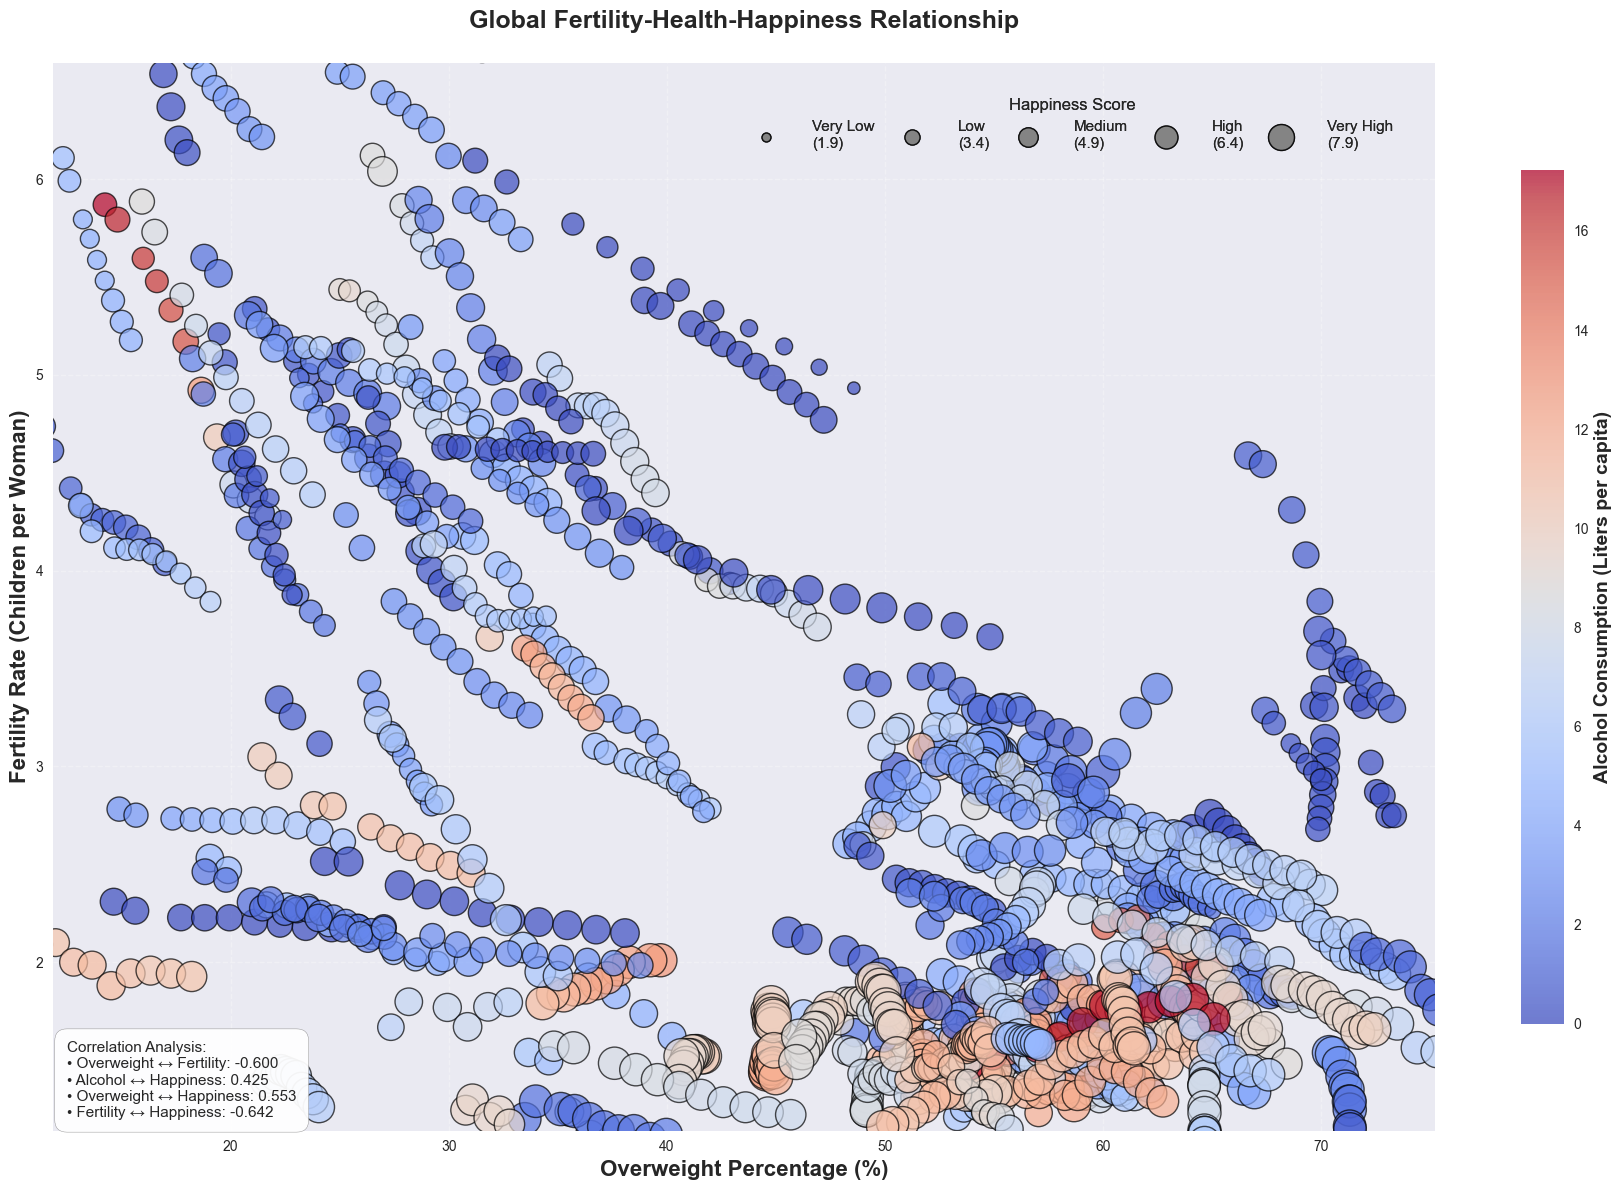

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Set up the plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")


# Remove missing values for our selected variables
plot_data = df[['overweight_pct', 'fertility_rate', 'alcohol_consumption', 'happiness_score']].dropna()

# Create custom colormap that combines alcohol and happiness
def create_combined_color(alcohol_val, happiness_val, alcohol_min, alcohol_max, happiness_min, happiness_max):
    """Create a color that combines alcohol (blue channel) and happiness (red channel)"""
    alcohol_norm = (alcohol_val - alcohol_min) / (alcohol_max - alcohol_min)
    happiness_norm = (happiness_val - happiness_min) / (happiness_max - happiness_min)
    
    # Use alcohol for blue and happiness for red, green as average
    return (happiness_norm * 0.8, (alcohol_norm + happiness_norm) * 0.4, alcohol_norm * 0.8)

# Calculate normalized values
alcohol_min, alcohol_max = plot_data['alcohol_consumption'].min(), plot_data['alcohol_consumption'].max()
happiness_min, happiness_max = plot_data['happiness_score'].min(), plot_data['happiness_score'].max()

# Create combined colors for each point
combined_colors = [
    create_combined_color(row['alcohol_consumption'], row['happiness_score'], 
                         alcohol_min, alcohol_max, happiness_min, happiness_max)
    for _, row in plot_data.iterrows()
]

# Create bubble plot with happiness as bubble size
fig, ax = plt.subplots(figsize=(18, 12))

# Calculate bubble sizes based on happiness score
happiness_min, happiness_max = plot_data['happiness_score'].min(), plot_data['happiness_score'].max()
bubble_sizes = 80 + (plot_data['happiness_score'] - happiness_min) / (happiness_max - happiness_min) * 600

# Create the bubble plot
bubble = ax.scatter(
    x=plot_data['overweight_pct'],
    y=plot_data['fertility_rate'],
    s=bubble_sizes,  # Size represents happiness score
    c=plot_data['alcohol_consumption'],  # Color represents alcohol consumption
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='black',
    linewidth=1.0,
    marker='o'
)

# Add colorbar for alcohol consumption
cbar = plt.colorbar(bubble, ax=ax, shrink=0.8)
cbar.set_label('Alcohol Consumption (Liters per capita)', fontsize=14, fontweight='bold')

# Set labels and title
ax.set_xlabel('Overweight Percentage (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Fertility Rate (Children per Woman)', fontsize=16, fontweight='bold')
ax.set_title('Global Fertility-Health-Happiness Relationship', 
             fontsize=18, fontweight='bold', pad=25)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Create 5 distinct bubble sizes for legend
happiness_range = np.linspace(happiness_min, happiness_max, 5)
size_range = 80 + (happiness_range - happiness_min) / (happiness_max - happiness_min) * 600

# Create size legend elements with 5 distinct sizes
size_legend_elements = [
    plt.scatter([], [], s=size_range[0], c='gray', alpha=0.8, 
                label=f'Very Low\n({happiness_range[0]:.1f})', edgecolors='black', linewidth=1),
    plt.scatter([], [], s=size_range[1], c='gray', alpha=0.8, 
                label=f'Low\n({happiness_range[1]:.1f})', edgecolors='black', linewidth=1),
    plt.scatter([], [], s=size_range[2], c='gray', alpha=0.8, 
                label=f'Medium\n({happiness_range[2]:.1f})', edgecolors='black', linewidth=1),
    plt.scatter([], [], s=size_range[3], c='gray', alpha=0.8, 
                label=f'High\n({happiness_range[3]:.1f})', edgecolors='black', linewidth=1),
    plt.scatter([], [], s=size_range[4], c='gray', alpha=0.8, 
                label=f'Very High\n({happiness_range[4]:.1f})', edgecolors='black', linewidth=1)
]

# Create HORIZONTAL legend for bubble sizes
size_legend = ax.legend(handles=size_legend_elements, 
                       loc='upper right', 
                       title='Happiness Score',
                       title_fontsize=12,
                       framealpha=0.95,
                       fontsize=11,
                       ncol=5,  # Horizontal layout with 5 columns
                       handletextpad=2.0,  # More padding between bubbles and text
                       columnspacing=1.5,   # Space between columns
                       markerscale=0.8,     # Slightly scale down markers in legend
                       bbox_to_anchor=(0.98, 0.98))  # Position in top-right corner

# Make the legend frame more rectangular to accommodate horizontal layout
for handle in size_legend.legend_handles:
    handle.set_sizes([handle.get_sizes()[0] * 0.8])  # Adjust size in legend

ax.add_artist(size_legend)
# Add correlation information with better formatting
corr_text = f"Correlation Analysis:\n" \
           f"• Overweight ↔ Fertility: {plot_data['overweight_pct'].corr(plot_data['fertility_rate']):.3f}\n" \
           f"• Alcohol ↔ Happiness: {plot_data['alcohol_consumption'].corr(plot_data['happiness_score']):.3f}\n" \
           f"• Overweight ↔ Happiness: {plot_data['overweight_pct'].corr(plot_data['happiness_score']):.3f}\n" \
           f"• Fertility ↔ Happiness: {plot_data['fertility_rate'].corr(plot_data['happiness_score']):.3f}"

ax.annotate(corr_text, xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=11, va='bottom', ha='left',
            bbox=dict(boxstyle="round,pad=0.8", facecolor='white', alpha=0.95, edgecolor='gray'))

# Adjust plot limits for better visualization
ax.set_xlim(plot_data['overweight_pct'].quantile(0.01), plot_data['overweight_pct'].quantile(0.99))
ax.set_ylim(plot_data['fertility_rate'].quantile(0.01), plot_data['fertility_rate'].quantile(0.99))

plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("happy.csv")
df.info()
print(df)

# Replace df with your DataFrame name if different
import pandas as pd
import numpy as np

countries_30 = [
 'United States','Canada','Mexico',                # North America
 'Brazil','Argentina','Chile','Colombia',          # Latin America
 'Germany','United Kingdom','France','Finland','Poland',  # Europe & Central Asia
 'Nigeria','Zambia','Kenya','Ghana','Ethiopia',    # Sub-Saharan Africa
 'Saudi Arabia','Turkey','Iran','Egypt',           # MENA
 'India','Pakistan','Bangladesh','Sri Lanka',      # South Asia
 'China','Japan','South Korea','Indonesia','Australia'   # East Asia & Pacific
]

# If your country names differ slightly, adapt strings above to match df['country'] entries.

df30 = df[df['country'].isin(countries_30)].copy()
print('Rows in 30-country subset:', len(df30))
print('Countries found:', df30['country'].unique())

# List of original (non-engineered) vars you said to focus on
orig_vars = [
 'education_expenditure_pct_gdp',
 'happiness_score',
 'overweight_pct',
 'obesity_yearly_change',
 'fertility_rate',
 'consumption_per_capita_usd',
 'alcohol_consumption',
 'corruption_index',
 'life_satisfaction',          # if same as happiness, treat carefully
 'gdp_per_capita_ppp',
 'health_expenditure_per_capita_usd',
 'inflation_pct',
 'internet_users_pct',
 'population',
 'suicide_rate',
 'unemployment_rate',
 'urban_population_pct'
]

# completeness per country-year and per country
completeness = df30.groupby('country')[orig_vars].apply(lambda g: g.notna().mean()).T
# completeness now has index=var, columns=countries
print('\nFraction of non-missing values (2011-2023) by country (1.0 = complete):')
print(completeness.round(2))

# Summary: percent of variables present (per country, averaged across years)
country_pct = df30.groupby('country').apply(lambda g: g[orig_vars].notna().sum().sum() / (g.shape[0]*len(orig_vars)))
country_pct = country_pct.sort_values(ascending=False)
print('\nAverage completeness per country (0-1):')
print(country_pct.round(3))

# If any country has very low completeness (e.g. <0.5) show it
low_coverage = country_pct[country_pct < 0.5]
if not low_coverage.empty:
    print('\nCountries with <50% completeness (consider replacing):')
    print(low_coverage)
else:
    print('\nAll countries have at least 50% completeness across the selected variables (good).')

# Save subset for convenience
df30.to_csv('df_30_countries.csv', index=False)
print('\nSaved data/df_30_countries.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            2646 non-null   object 
 1   year                               2646 non-null   int64  
 2   education_expenditure_pct_gdp      1878 non-null   float64
 3   happiness_score                    1889 non-null   float64
 4   happiness_global_percentile        1889 non-null   float64
 5   very_high_happiness                1889 non-null   object 
 6   very_low_happiness                 1889 non-null   object 
 7   overweight_pct                     2208 non-null   float64
 8   obesity_yearly_change              2208 non-null   float64
 9   obesity_global_percentile          2208 non-null   float64
 10  high_obesity                       2208 non-null   object 
 11  very_high_obesity                  2208 non-null   objec

In [18]:
import plotly.express as px
import pandas as pd

# --- CONFIGURATION ---
years_to_plot = [2018, 2022]

# 1. Define Variable Sets
econ_vars = ['happiness_score', 'gdp_per_capita_ppp', 'consumption_per_capita_usd', 
             'unemployment_rate', 'inflation_pct']
social_vars = ['happiness_score', 'internet_users_pct', 'corruption_index', 
               'suicide_rate', 'overweight_pct']

# 2. LIST OF VARIABLES TO REVERSE (Top = Low Value)
vars_to_reverse = ['unemployment_rate', 'inflation_pct', 'suicide_rate', 'overweight_pct']

# 3. LABELS
labels_config = {
    'happiness_score': 'Happiness Score',
    'gdp_per_capita_ppp': 'GDP PPP',
    'consumption_per_capita_usd': 'Consumption',
    'internet_users_pct': 'Internet Access %',
    'corruption_index': 'Corruption (High is Clean)',
    'unemployment_rate': 'Unemployment (Up is Better)',
    'inflation_pct': 'Inflation (Up is Better)',
    'suicide_rate': 'Suicide Rate (Up is Better)',
    'overweight_pct': 'Obesity % (Up is Better)'
}

# 4. MASTER LIMITS (REAL, POSITIVE RANGES)
# UPDATED: GDP is now capped at 80k
LIMITS = {
    'happiness_score': [2, 8],
    'gdp_per_capita_ppp': [0, 80000],    # <--- UPDATED to 80k
    'consumption_per_capita_usd': [0, 60000],
    'unemployment_rate': [0, 20],        # 0 to 20 (Positive!)
    'inflation_pct': [0, 20],            # 0 to 20 (Positive!)
    'internet_users_pct': [0, 100],
    'corruption_index': [0, 100],
    'suicide_rate': [0, 30],             
    'overweight_pct': [5, 80]            
}

# --- HELPER FUNCTION ---
def prep_data(df_in, year, cols_needed):
    dff = df_in[df_in['year'] == year].copy()
    dff = dff.dropna(subset=cols_needed)
    
    for col in cols_needed:
        if col in LIMITS:
            lower, upper = LIMITS[col]
            # Clip data so outliers (e.g. GDP > 80k) sit at the edge
            dff[col] = dff[col].clip(lower=lower, upper=upper)
    return dff

def add_guide_annotation(fig):
    fig.add_annotation(
        text="<b>HOW TO READ:</b> All axes aligned so <b>Higher = Better</b>.<br>"
             "For metrics like Inflation, 0% is at the Top.",
        xref="paper", yref="paper", x=0.5, y=-0.25, showarrow=False,
        font=dict(size=12, color="gray"), bgcolor="white", bordercolor="gray", borderwidth=1
    )
    fig.update_layout(margin=dict(b=100))

# --- PLOTTING LOOP ---
for year in years_to_plot:
    
    # ---------------------------
    # CHART A: ECONOMICS
    # ---------------------------
    df_econ = prep_data(df, year, econ_vars)
    if not df_econ.empty:
        fig_econ = px.parallel_coordinates(
            df_econ,
            dimensions=econ_vars,
            color='happiness_score',
            color_continuous_scale=px.colors.diverging.Tealrose,
            title=f"Economic Factors: {year} ",
            labels=labels_config
        )
        # APPLY RANGES (AND REVERSE SPECIFIC AXES)
        for dim in fig_econ.data[0].dimensions:
            for col, label in labels_config.items():
                if label == dim.label and col in LIMITS:
                    lower, upper = LIMITS[col]
                    # If it's a "Bad" variable, swap the range: [Max, Min]
                    if col in vars_to_reverse:
                        dim.range = [upper, lower] # e.g., [20, 0]
                    else:
                        dim.range = [lower, upper] # e.g., [0, 80000]
        
        add_guide_annotation(fig_econ)
        
        # Enable High-Res Download (Solution 2)
        config_econ = {
            'toImageButtonOptions': {
                'format': 'svg', 'filename': f'Economics_{year}_PositiveAxis',
                'height': 900, 'width': 1600, 'scale': 1
            }
        }
        fig_econ.show(config=config_econ)

    # ---------------------------
    # CHART B: SOCIAL
    # ---------------------------
    df_social = prep_data(df, year, social_vars)
    if not df_social.empty:
        fig_social = px.parallel_coordinates(
            df_social,
            dimensions=social_vars,
            color='happiness_score',
            color_continuous_scale=px.colors.diverging.Tealrose,
            title=f"Social Factors: {year} ",
            labels=labels_config
        )
        # APPLY RANGES (AND REVERSE SPECIFIC AXES)
        for dim in fig_social.data[0].dimensions:
            for col, label in labels_config.items():
                if label == dim.label and col in LIMITS:
                    lower, upper = LIMITS[col]
                    if col in vars_to_reverse:
                        dim.range = [upper, lower] 
                    else:
                        dim.range = [lower, upper]

        add_guide_annotation(fig_social)
        
        config_social = {
            'toImageButtonOptions': {
                'format': 'svg', 'filename': f'Social_{year}_PositiveAxis',
                'height': 900, 'width': 1600, 'scale': 1
            }
        }
        fig_social.show(config=config_social)

In [22]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Ensure numpy is imported for log calculation
df30['log_gdp'] = np.log1p(df30['gdp_per_capita_ppp'])

def heatmap_gdp_corruption(year=2019, x_bins=12, y_bins=10):
    dfy = df30[df30['year']==year].dropna(subset=['log_gdp','corruption_index','happiness_score','population_millions'])
    
    if dfy.empty:
        raise ValueError(f"No data for year {year}")

    # 1. Define bins
    x_edges = np.linspace(dfy['log_gdp'].min(), dfy['log_gdp'].max(), x_bins+1)
    y_edges = np.linspace(dfy['corruption_index'].min(), dfy['corruption_index'].max(), y_bins+1)

    # 2. Cut data into bins
    dfy['xbin'] = pd.cut(dfy['log_gdp'], bins=x_edges, labels=range(x_bins), include_lowest=True)
    dfy['ybin'] = pd.cut(dfy['corruption_index'], bins=y_edges, labels=range(y_bins), include_lowest=True)

    # 3. Aggregate
    # We group by bins and calculate mean happiness
    grouped = dfy.groupby(['xbin', 'ybin'])['happiness_score'].mean()

    # 4. SAFETY STEP: Reindex to ensure full grid
    # This prevents the heatmap from breaking if some bins are empty
    full_idx = pd.MultiIndex.from_product([range(x_bins), range(y_bins)], names=['xbin', 'ybin'])
    pivot = grouped.reindex(full_idx).unstack(fill_value=np.nan)

    # 5. Prepare Grid for Plotly
    z = pivot.values  # This is now guaranteed to be shape (x_bins, y_bins)
    
    # Calculate centers for axis labels
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    # 6. Plot
    fig = go.Figure()

    # Heatmap Layer
    fig.add_trace(go.Heatmap(
        z = z.T, # Transpose to match Plotly's (y, x) expectation
        x = x_centers,
        y = y_centers,
        colorscale='RdYlBu', # Red=Low Happiness, Blue=High
        zmin=df30['happiness_score'].min(), 
        zmax=df30['happiness_score'].max(),
        colorbar=dict(title='Mean Happiness'),
        hoverongaps=False
    ))

    # Scatter Layer (Overlay Countries)
    fig.add_trace(go.Scatter(
        x = dfy['log_gdp'],
        y = dfy['corruption_index'],
        mode='markers', # Removed text to avoid clutter, added hover
        marker=dict(
            size=np.clip(dfy['population_millions']**0.5, 5, 30), 
            color='black', 
            opacity=0.4,
            line=dict(width=1, color='white')
        ),
        text = dfy['country'],
        hoverinfo='text',
        hovertext = dfy.apply(lambda r: f"<b>{r.country}</b><br>Happiness: {r.happiness_score:.1f}<br>Corruption: {r.corruption_index:.1f}", axis=1)
    ))

    fig.update_layout(
        title=f'Heatmap-Bubble Plot: Wealth versus Corruption ({year})',
        xaxis_title='Log GDP (Wealth)', 
        yaxis_title='Corruption Index (Higher = Cleaner)',
        width=900, height=700
    )
    return fig

# Run the fixed function
fig_h = heatmap_gdp_corruption(year=2022, x_bins=14, y_bins=10)
fig_h.show()

In [17]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# --- 1. DATA PREP ---
df30 = df30.sort_values(['country', 'year']).copy()
if 'log_gdp' not in df30.columns:
    df30['log_gdp'] = np.log1p(df30['gdp_per_capita_ppp'])

cols_needed = ['country', 'year', 'log_gdp', 'happiness_score', 'corruption_index', 'population_millions']
plot_df = df30[cols_needed].dropna(subset=['log_gdp', 'happiness_score']).copy()
plot_df['corruption_index'] = plot_df['corruption_index'].fillna(plot_df['corruption_index'].median())

def get_text_position(row):
    if row['log_gdp'] > 10.5:
        return "top left"
    elif 8.5 < row['log_gdp'] < 9.5:
        return "bottom center"
    else:
        return "top center"

years = sorted(plot_df['year'].unique())
fig_full = go.Figure()

# --- 2. ADD SOLID HISTORY LINES ---
for country, g in plot_df.groupby('country'):
    fig_full.add_trace(go.Scatter(
        x=g['log_gdp'],
        y=g['happiness_score'],
        mode='lines',
        line=dict(width=1.5, color='#e0e0e0'),
        opacity=1,  # fully solid lines now
        hoverinfo='skip',
        showlegend=False
    ))

# --- 3. CREATE ANIMATION FRAMES OF SOLID CIRCLES ---
frames = []
for yr in years:
    dfy = plot_df[plot_df['year'] == yr].copy()
    top_pop = dfy.nlargest(5, 'population_millions')['country'].tolist()
    top_rich = dfy.nlargest(3, 'log_gdp')['country'].tolist()
    dfy['text_label'] = dfy.apply(lambda r: r['country'] if r['country'] in top_pop + top_rich else "", axis=1)
    dfy['text_pos'] = dfy.apply(get_text_position, axis=1)
    
    frames.append(go.Frame(
        data=[
            go.Scatter(
                x=dfy['log_gdp'],
                y=dfy['happiness_score'],
                mode='markers+text',
                marker=dict(
                    size=np.clip(dfy['population_millions'], 0, None),
                    sizemode='area',
                    sizeref=max(plot_df['population_millions'])/800,
                    sizemin=5,
                    color=dfy['corruption_index'].values,
                    colorscale='RdYlGn',
                    cmin=0, cmax=100,
                    showscale=True,
                    opacity=1,  # keep circles fully opaque
                    colorbar=dict(title='Corruption<br>Index', thickness=15, x=1.02),
                    line=dict(width=1, color='#444')
                ),
                text=dfy['text_label'],
                textposition=dfy['text_pos'],
                textfont=dict(size=11, color="#333", family="Arial"),
                hovertemplate="<b>%{text}</b><br>GDP: %{x:.2f}<br>Happy: %{y:.2f}<br>Corr: %{marker.color:.0f}<extra></extra>"
            )
        ],
        name=str(yr)
    ))

fig_full.frames = frames

# --- 4. LAYOUT ---
fig_full.update_layout(
    title='<b>The Pursuit of Happiness (2011-2023)</b><br><span style="color:gray; font-size:14px">Grey Lines = History | Colored Bubbles = Current Year (Green=Clean, Red=Corrupt)</span>',
    xaxis=dict(title='<b>Log GDP (Wealth)</b>', range=[7, 11.8], showgrid=True, gridcolor='#f0f0f0'),
    yaxis=dict(title='<b>Happiness Score</b>', range=[3, 8], showgrid=True, gridcolor='#f0f0f0'),
    width=1100, height=750,
    plot_bgcolor='white',
    margin=dict(r=100),
    updatemenus=[dict(
        type='buttons', showactive=False,
        y=1.15, x=1.25, xanchor='right', yanchor='top',
        buttons=[
            dict(label='▶ Play', method='animate', args=[None, {'frame': {'duration': 600, 'redraw': True}, 'fromcurrent': True}]),
            dict(label='⏸ Pause', method='animate', args=[[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}])
        ]
    )],
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "Year: ", "font": {"size": 20}},
        "pad": {"t": 50},
        "steps": [{"args": [[str(y)], {"frame": {"duration": 600, "redraw": True}, "mode": "immediate"}], "label": str(y), "method": "animate"} for y in years]
    }]
)

fig_full.show()


In [13]:
import plotly.express as px
import pandas as pd
import numpy as np

# 1. Map Income Groups
income_map = {'Low income': 0, 'High income': 1}
df_plot = df.copy() # Uses the full dataset (All Years)
df_plot['income_code'] = df_plot['income_group'].map(income_map)
df_plot = df_plot.dropna(subset=['income_code'])

# 2. Log Transform Health
df_plot['log_health_exp'] = np.log10(df_plot['health_expenditure_per_capita_usd'] + 1)

# 3. Define Columns
numeric_cols = ['happiness_score', 'log_health_exp', 'overweight_pct', 'fertility_rate']

# 4. Plot with New Title
fig = px.parallel_coordinates(
    df_plot,
    dimensions=numeric_cols,
    color='income_code', 
    color_continuous_scale=[
        (0.0, 'rgba(255, 165, 0, 0.3)'),  # Orange (Poor)
        (1.0, 'rgba(0, 0, 255, 0.3)')     # Blue (Rich)
    ],
    labels={
        'happiness_score': 'Happiness',
        'log_health_exp': 'Health Exp (Log $)', 
        'overweight_pct': 'Obesity %',
        'fertility_rate': 'Fertility Rate'
    },
    # --- UPDATED HEADING ---
    title="Global Divide: High Income (Blue) vs Low Income (Orange) [Data: 2011-2023]"
)

# 5. Flip Axes Manually (So Top = "Modern/Healthy")
for dim in fig.data[0].dimensions:
    if dim.label == 'Obesity %':
        dim.range = [80, 0] # Flip: 0 (Low Obesity) is Top
    if dim.label == 'Fertility Rate':
        dim.range = [7, 0]  # Flip: 0 (Low Fertility) is Top

fig.update_layout(coloraxis_showscale=False)
fig.show()

## Asjad Visualisations


In [14]:
import pandas as pd
df = pd.read_csv('HappinesssGlobalData_v6.csv')
import numpy as np

# 1. Convert specific object columns to numeric
numeric_cols_to_convert = ['inflation_yoy_increase', 'unemployment_yearly_change', 'unemployment_growth_rate']
for col in numeric_cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Convert boolean-like object columns to boolean type
boolean_cols_to_convert = [
    'very_high_happiness', 'very_low_happiness', 'high_obesity', 'very_high_obesity',
    'suicide_very_high_risk', 'suicide_high_risk', 'suicide_moderate_risk', 'suicide_low_risk',
    'unemployment_very_high', 'unemployment_high', 'unemployment_moderate', 'unemployment_low',
    'highly_urbanized', 'moderately_urbanized', 'low_urbanized', 'very_low_urbanized', 'fully_urbanized'
]
# Convert to boolean, NaNs will be left as NaN for now and handled in step 4
for col in boolean_cols_to_convert:
    df[col] = df[col].astype(object) # Ensure it's object type before converting to bool, otherwise 'NaN' strings might become True
    df[col] = df[col].replace({True: True, False: False, np.nan: np.nan})
    df[col] = df[col].astype('boolean') # Use 'boolean' dtype to allow NaNs

# 3. Identify and impute missing values in numerical columns with their medians
# Get all numerical columns (float64, int64, and the newly converted ones)
numerical_cols = df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
# 4. Identify and impute missing values in boolean columns with False
boolean_cols = df.select_dtypes(include='boolean').columns
for col in boolean_cols:
    if df[col].isnull().any():
        df[col].fillna(False, inplace=True)
# 5. Identify and impute missing values in categorical columns with their modes
categorical_cols_to_impute = ['region', 'inflation_category', 'income_group']
for col in categorical_cols_to_impute:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
# 1. Select a set of numerical columns likely to influence 'happiness_score'
numerical_features = [
    'gdp_per_capita_ppp',
    'life_satisfaction',
    'corruption_index',
    'education_expenditure_pct_gdp',
    'health_expenditure_per_capita_usd',
    'internet_users_pct',
    'unemployment_rate'
]

# Add 'happiness_score' to the list for correlation calculation
columns_for_correlation = numerical_features + ['happiness_score']

# 2. Calculate the Pearson correlation matrix for these selected numerical columns
correlation_matrix = df[columns_for_correlation].corr(method='pearson')

# 3. Display the correlations of these columns with 'happiness_score' in descending order
happiness_correlations = correlation_matrix['happiness_score'].drop('happiness_score')

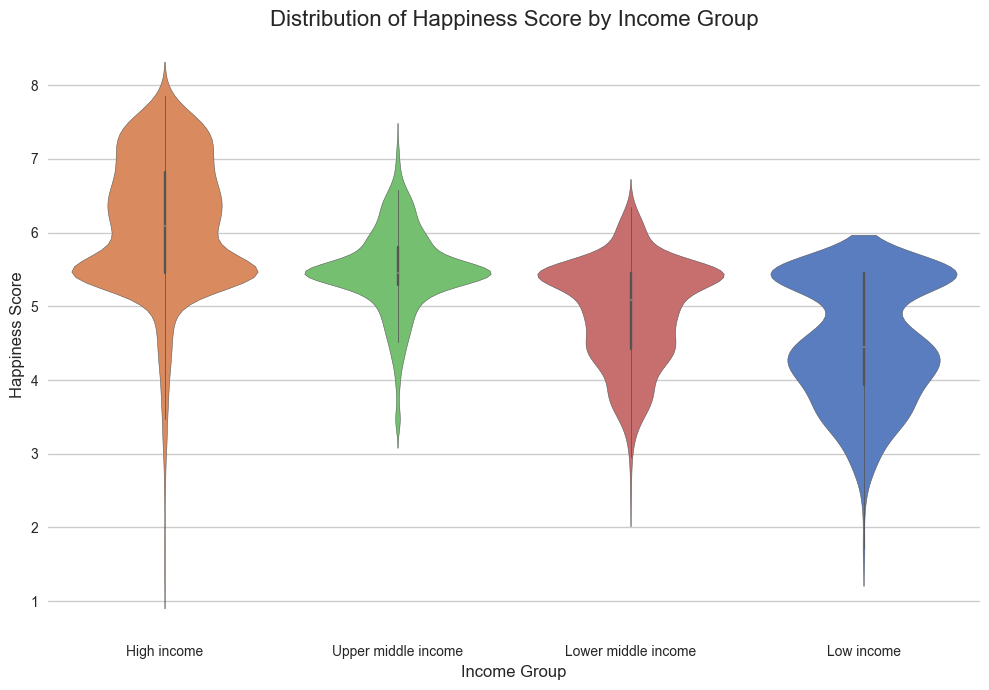

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
# 3. Violin plot: Distribution of happiness_score across income_group categories
# Define the order for income groups
income_group_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

plt.figure(figsize=(10, 7))
sns.violinplot(data=df, x='income_group', y='happiness_score', order=income_group_order, palette='muted', hue='income_group', legend=False)
plt.title('Distribution of Happiness Score by Income Group', fontsize=16)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.tight_layout()
plt.show()


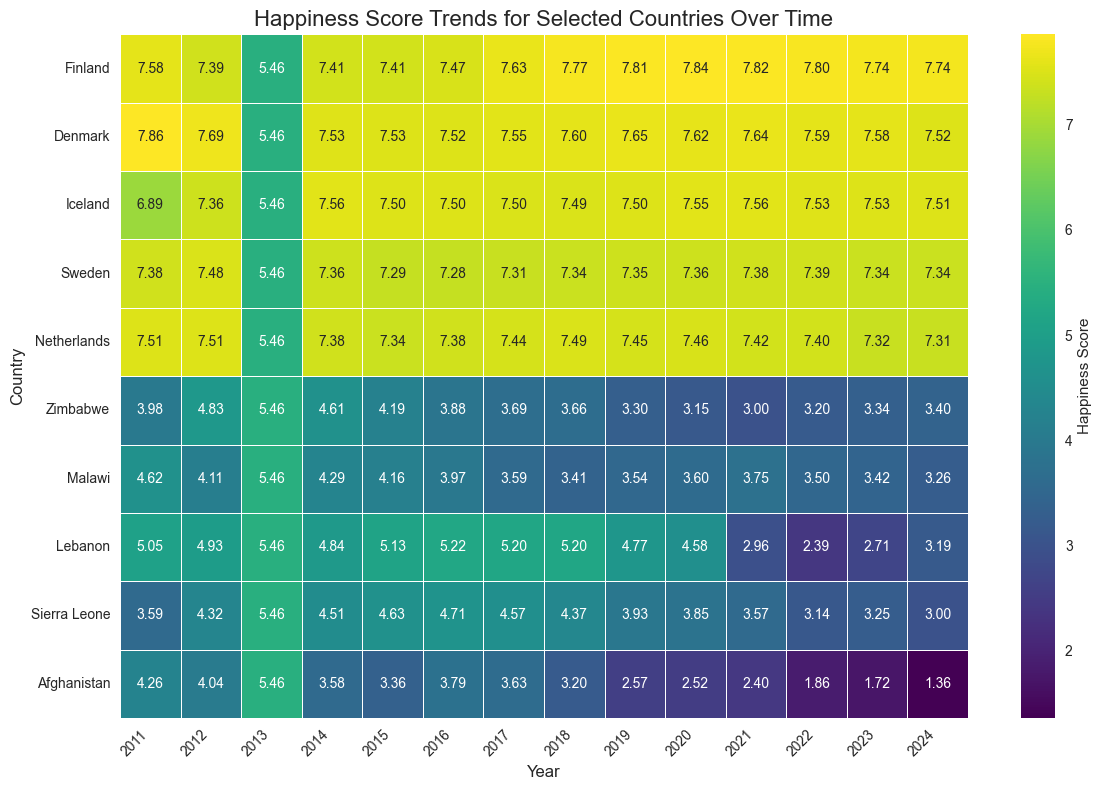

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# 1. Get top 5 happiest and bottom 5 unhappiest countries based on the latest year
latest_year = df['year'].max()
df_latest_year = df[df['year'] == latest_year]

top_5_happiest_countries = df_latest_year.nlargest(5, 'happiness_score')['country'].tolist()
bottom_5_unhappiest_countries = df_latest_year.nsmallest(5, 'happiness_score')['country'].tolist()

selected_countries = top_5_happiest_countries + bottom_5_unhappiest_countries

# Filter the original DataFrame for these selected countries
df_filtered_countries = df[df['country'].isin(selected_countries)]

# 2. Create a pivot table
happiness_pivot = df_filtered_countries.pivot_table(
    index='country',
    columns='year',
    values='happiness_score'
)

# Sort the pivot table by the latest year's happiness score to group similar countries
happiness_pivot = happiness_pivot.sort_values(by=latest_year, ascending=False)

# 3. Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    happiness_pivot,
    annot=True,     # Annotate cells with the happiness score
    fmt=".2f",      # Format annotations to two decimal places
    cmap="viridis", # Color map
    linewidths=.5,  # Add lines between cells
    cbar_kws={'label': 'Happiness Score'}
)
plt.title('Happiness Score Trends for Selected Countries Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()